<div style='text-align: center'>
    <p style='font-size:50px; margin-bottom: 0px'>Statistics</p>
    <o style='font-size:20px;'>This notebook handles calculating stats for all variations and putting them into a table</p>
</div>

In [1]:
import cogsworth
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from astropy.coordinates import SkyCoord

import sys
sys.path.append('../src')
import plotting, helpers, constants
from importlib import reload

In [2]:
%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [35]:
reload(constants)
files = ["fiducial_m2min", 'imf_1.9', 'imf_2.7', 'porb_slope_0', 'porb_slope_m1', 'porb_max_1000', 'q_power_law_m1', 'q_power_law_p1', 'qmin_pre_ms']
labels = ["Fiducial", r"$\alpha_{\rm imf} = -1.9$", r"$\alpha_{\rm imf} = -2.7$", r"$\pi = 0.0$", r"$\pi = -1.0$", r"$P_{\rm orb, max} = 1000$ days", r"$\kappa = -1.0$", r"$\kappa = 1.0$", r"$q_{\rm min} = -1$"]
colours = [plt.get_cmap("tab10")(i) for i in range(len(files))]
# colours = [constants.FILE_TO_COLOUR[f] for f in files]

In [36]:
pops, data = helpers.load_postprocessed_pops(files, labels, colours)

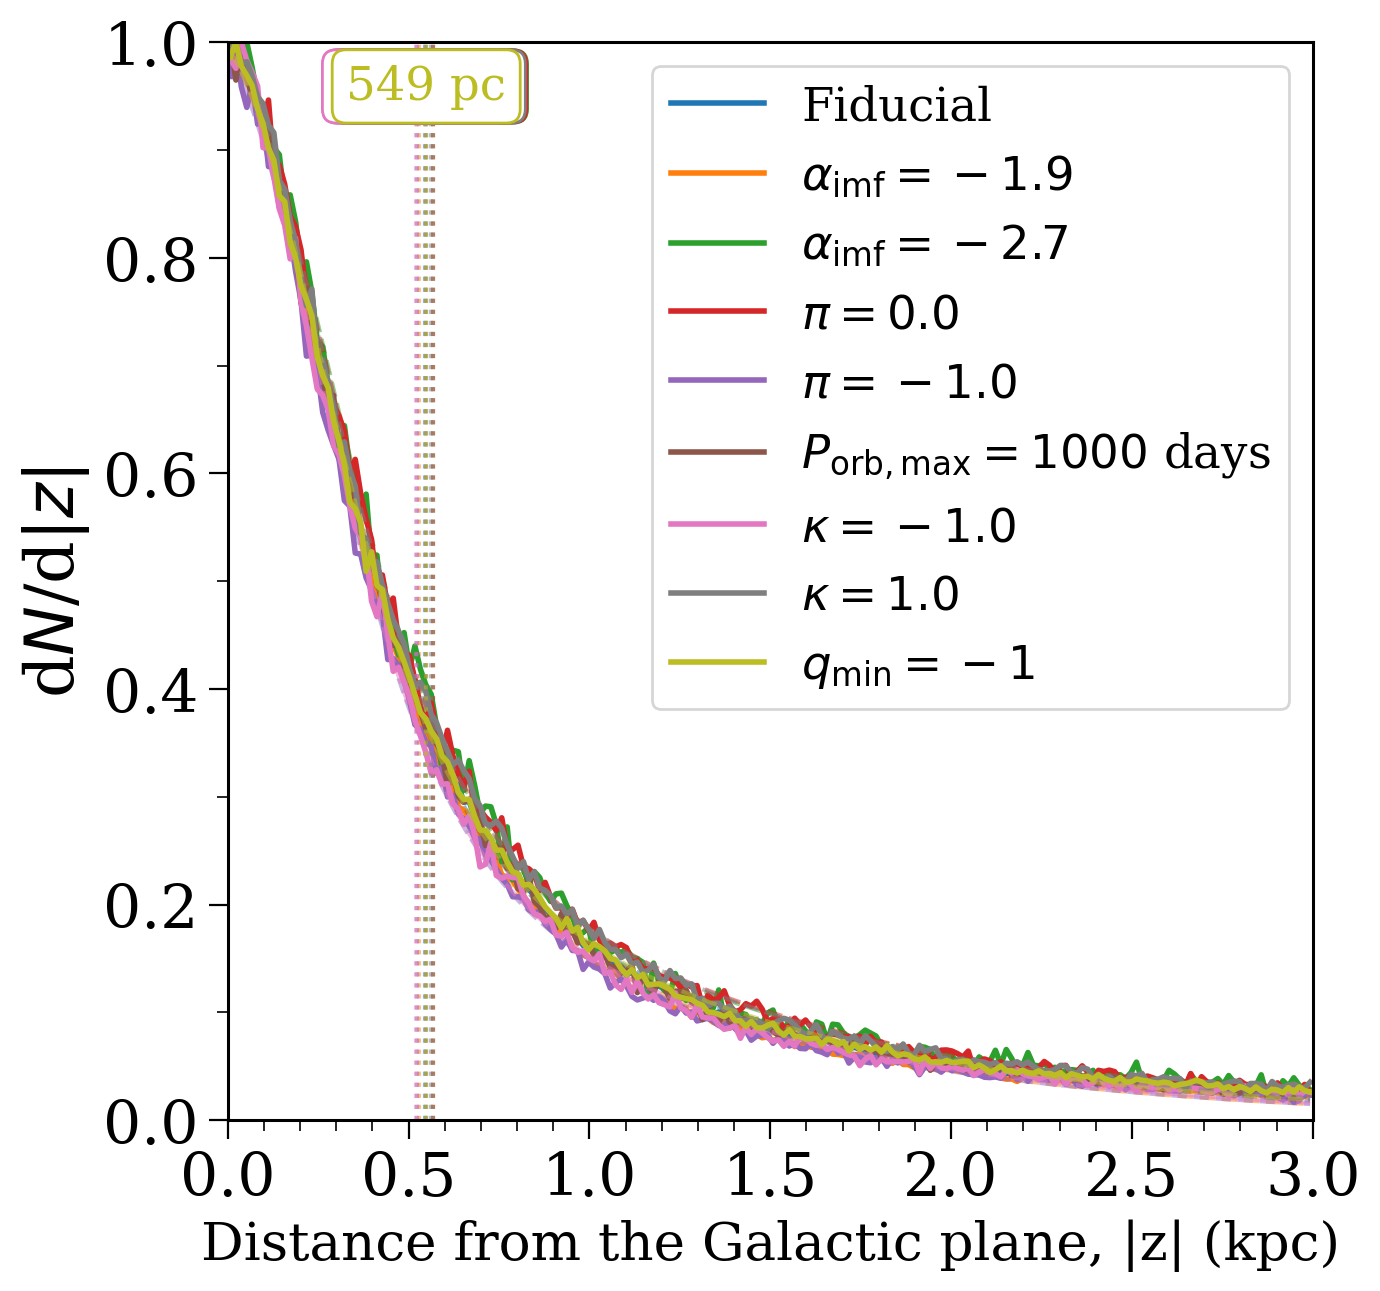

In [37]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for pop in pops:

    plotting.estimate_scale_height(
        z=data[pop.label]["pos"]["BH"][:, 2][~data[pop.label]["escaped"]["BH"]],
        plot=True,
        label=pop.label,
        colour=pop.colour,
        show=False,
        fig=fig,
        ax=ax,
        bins=np.linspace(0, 3, 201),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=2,
        scale_height_loc=0.98,
        R=None,
    )

# add minor ticks every 0.1 kpc
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

# plt.savefig("../plots/scale_height_kicks.pdf", format="pdf", bbox_inches='tight')

plt.show()

In [8]:
print("Average BH masses:")
print("------------------")

for pop in pops:
    mass = data[pop.label]["mass"]

    average_escaped_BH_mass = np.mean(mass["BH"][data[pop.label]["escaped"]["BH"]])
    average_bound_BH_mass = np.mean(mass["BH"][~data[pop.label]["escaped"]["BH"]])

    avg_bound_BH_close_to_disc = np.mean(mass["BH"][(
        ~data[pop.label]["escaped"]["BH"] &
        (abs(data[pop.label]["pos"]["BH"][:, 2]) < 1)
    )])

    avg_bound_BH_far_from_disc = np.mean(mass["BH"][(
        ~data[pop.label]["escaped"]["BH"] &
        (abs(data[pop.label]["pos"]["BH"][:, 2]) >= 1)
    )])

    print(f"{pop.label}")
    print(f"  Escaped: {average_escaped_BH_mass:.1f} Msun")
    print(f"  Bound:   {average_bound_BH_mass:.1f} Msun")
    print(f"    Close to disc (<1 kpc):  {avg_bound_BH_close_to_disc:.1f} Msun")
    print(f"    Far from disc (>=1 kpc): {avg_bound_BH_far_from_disc:.1f} Msun")
    print()

Average BH masses:
------------------
Fiducial
  Escaped: 5.2 Msun
  Bound:   9.3 Msun
    Close to disc (<1 kpc):  10.1 Msun
    Far from disc (>=1 kpc): 7.7 Msun

$\alpha_{\rm imf} = -1.9$
  Escaped: 5.2 Msun
  Bound:   10.1 Msun
    Close to disc (<1 kpc):  10.9 Msun
    Far from disc (>=1 kpc): 8.1 Msun

$\alpha_{\rm imf} = -2.7$
  Escaped: 5.2 Msun
  Bound:   8.7 Msun
    Close to disc (<1 kpc):  9.3 Msun
    Far from disc (>=1 kpc): 7.4 Msun

$\pi = 0.0$
  Escaped: 5.2 Msun
  Bound:   9.1 Msun
    Close to disc (<1 kpc):  9.9 Msun
    Far from disc (>=1 kpc): 7.5 Msun

$\pi = -1.0$
  Escaped: 5.2 Msun
  Bound:   9.3 Msun
    Close to disc (<1 kpc):  10.0 Msun
    Far from disc (>=1 kpc): 7.7 Msun

$P_{\rm orb, max} = 1000$ days
  Escaped: 5.2 Msun
  Bound:   9.4 Msun
    Close to disc (<1 kpc):  10.1 Msun
    Far from disc (>=1 kpc): 7.7 Msun

$\kappa = -1.0$
  Escaped: 5.2 Msun
  Bound:   8.9 Msun
    Close to disc (<1 kpc):  9.5 Msun
    Far from disc (>=1 kpc): 7.5 Msun

$\kap

In [11]:
z_range = np.geomspace(0.1, 10, 500)

init_abs_z = np.abs(data[pops[0].label]["init_z"]["BH"])

mean_masses = helpers.get_average_mass_at_z(
    abs_zs=[np.abs(data[pop.label]["pos"]["BH"][:, 2]) for pop in pops] + [init_abs_z],
    bh_masses=[data[pop.label]["mass"]["BH"] for pop in pops] + [data[pops[0].label]["mass"]["BH"]],
    z_range=z_range,
    window_width=0.1
)

z_maxes = [10] * len(pops) + [3]

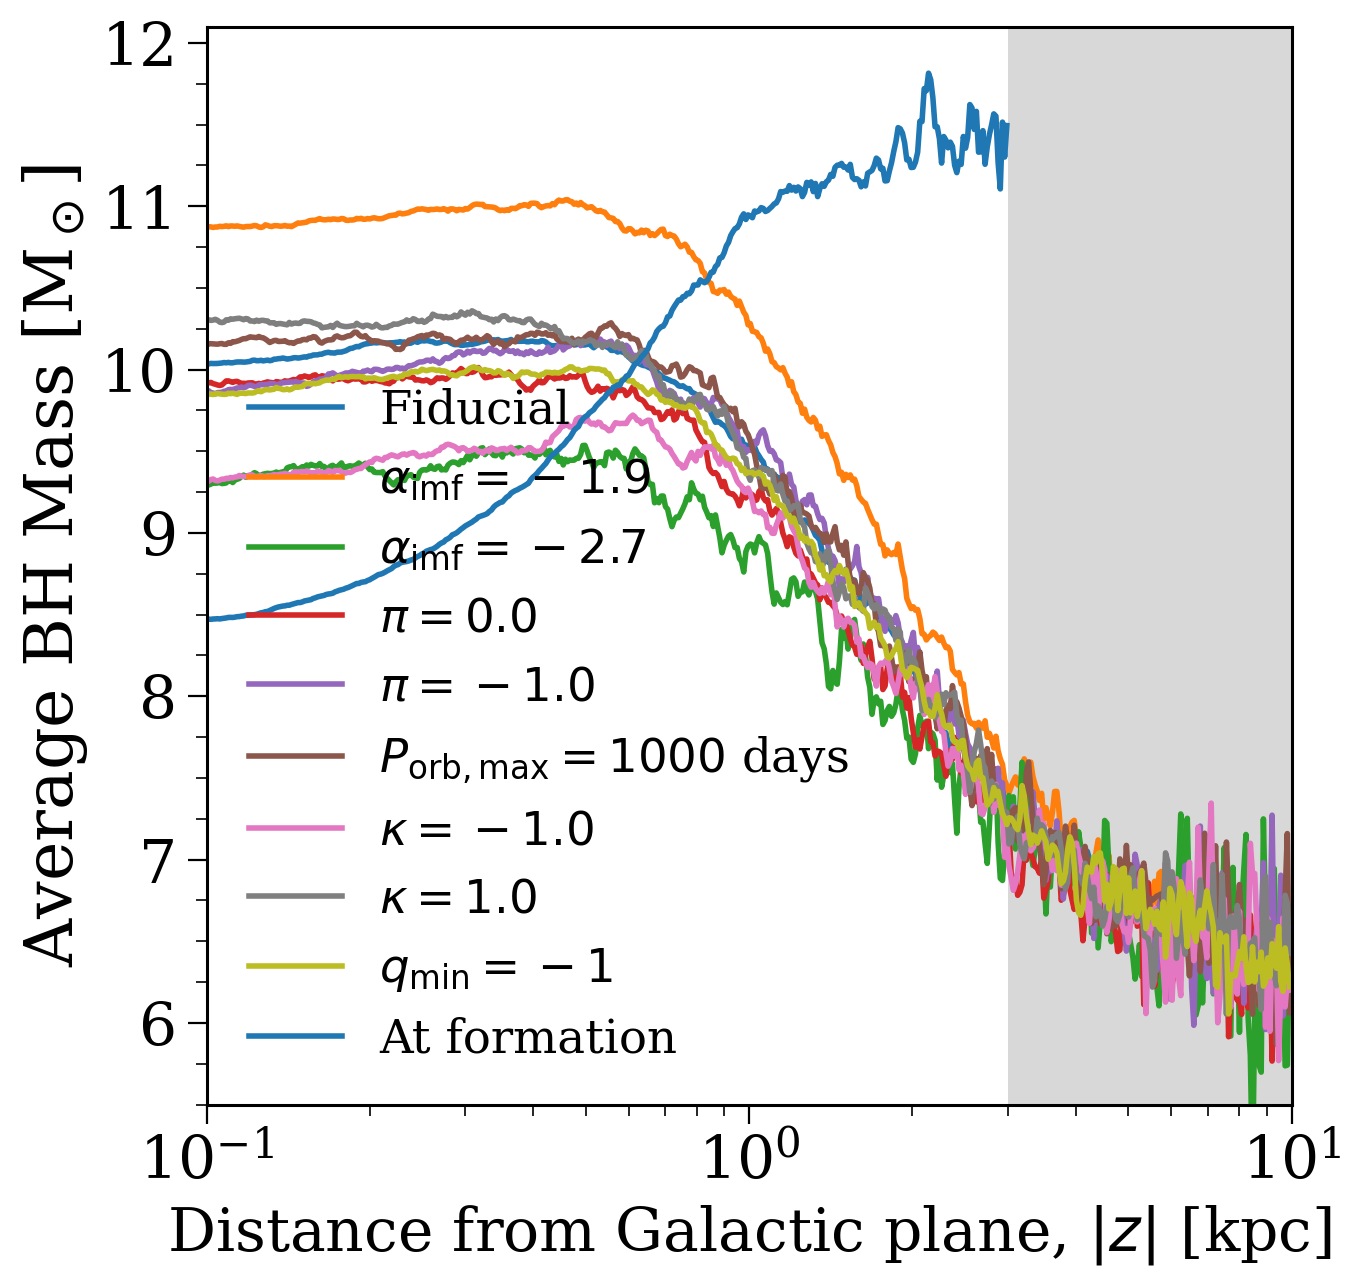

(<Figure size 700x700 with 1 Axes>,
 <Axes: xlabel='Distance from Galactic plane, $|z|$ [kpc]', ylabel='Average BH Mass [M$_\\odot$]'>)

In [12]:
reload(plotting)
plotting.plot_avg_mass_vs_z(
    mean_masses=mean_masses,
    labels=labels + ["At formation"],
    colours=colours + ["tab:blue"],
    z_maxes=z_maxes,
    z_range=z_range,
    legend_kwargs={
        "title": None,
        "fontsize": 0.7*fs,
        "title_fontsize": 0.6*fs,
        "loc": "lower left",
        "frameon": False
    },
    ax_kwargs={
        "ylim": (5.5, 12.1)
    },
    # save="../plots/average_bh_mass_vs_z_kicks.pdf",
)

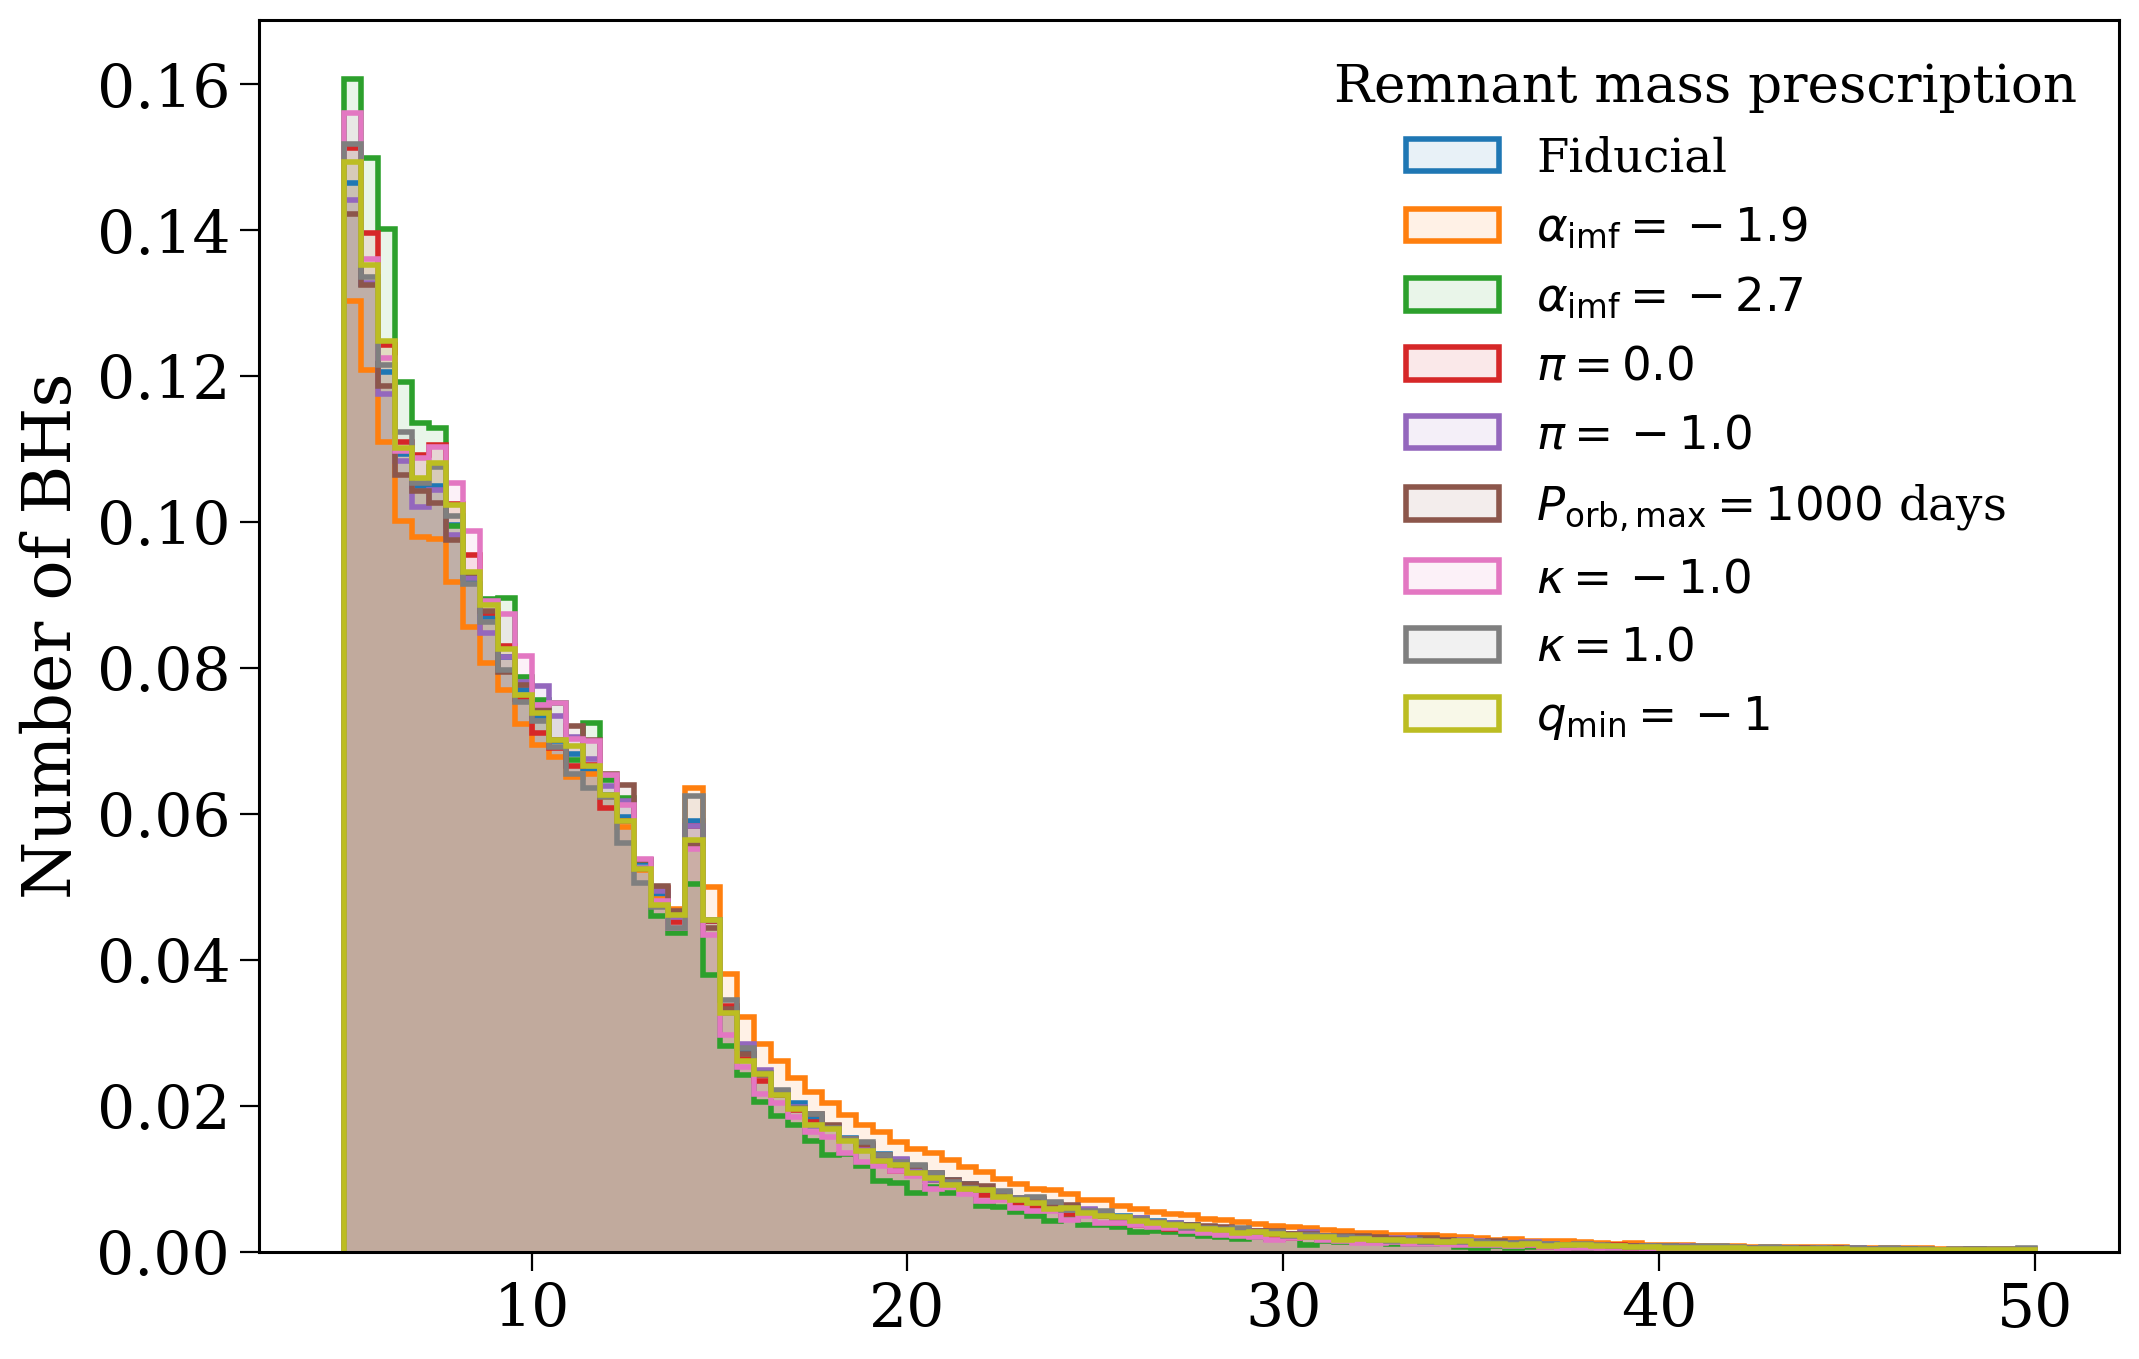

(<Figure size 1200x800 with 1 Axes>, <Axes: ylabel='Number of BHs'>)

In [19]:
plotting.plot_mass_histogram(
    pops=pops,
    labels=[pop.label for pop in pops],
    data=data,
    bins=np.linspace(5, 50, 100),
    co_type="BH",
    xlabel=r"",
    ylabel=r"Number of BHs",
    alpha=0.1,
    legend_title="Remnant mass prescription",
    density=True,
)

In [24]:
for pop in pops:
    print((data[pop.label]["n_BH"] / data[pop.label]["mass_binaries"]) * 6e10 / 1e8)

1.8708271430053705
3.9398018027128683
0.6492042742329471
1.6386180293024888
1.8851461150014153
1.7574995456676554
1.4997571246215025
1.8768491953223256
1.8632944500823743


In [39]:
for pop in pops:
    bh_star = ((data[pop.label]["sep"]["BH"] > 0) & (data[pop.label]["companion"]["BH"] < 10))
    print(pop.label, bh_star.sum() / data[pop.label]["mass_binaries"] * 6e10 / 1e5)

Fiducial 1.6681323677804463
$\alpha_{\rm imf} = -1.9$ 5.077397120928741
$\alpha_{\rm imf} = -2.7$ 0.14467042434438504
$\pi = 0.0$ 2.221358911453415
$\pi = -1.0$ 0.8747081106889352
$P_{\rm orb, max} = 1000$ days 1.5187314026494039
$\kappa = -1.0$ 44.319276381365135
$\kappa = 1.0$ 0.06675701478215999
$q_{\rm min} = -1$ 0.043138652405867145


In [40]:
from cosmic.sample import InitialBinaryTable

In [102]:
ibt, mass_singles, mass_binaries, n_singles, n_binaries = InitialBinaryTable.sampler(
    "independent", [13, 14], range(16),
    binfrac_model=1.0, primary_model="kroupa01",
    ecc_model="sana12", porb_model="sana12", qmin=-1,
    SF_start=13700.0, SF_duration=0.0, met=0.02, size=10, nproc=1,
    total_mass=1e6, sampling_target="total_mass"
)
mass_binaries, len(ibt), ((ibt["mass_1"] > 8)).sum(), ((ibt["mass_1"] > 16) & (ibt["mass_2"] < 8)).sum()

(np.float64(1003773.8995606856), 25564, np.int64(6913), np.int64(583))

In [103]:
ibt, mass_singles, mass_binaries, n_singles, n_binaries = InitialBinaryTable.sampler(
    "independent", [13, 14], range(16),
    binfrac_model=1.0, primary_model="kroupa01",
    ecc_model="sana12", porb_model="sana12", qmin=-1,
    SF_start=13700.0, SF_duration=0.0, met=0.02, size=200_000, nproc=1,
)
mass_binaries, len(ibt), ((ibt["mass_1"] > 8)).sum(), ((ibt["mass_1"] > 16) & (ibt["mass_2"] < 8)).sum()

(np.float64(7982932.751959837), 203627, np.int64(55749), np.int64(4741))

In [104]:
ibt, mass_singles, mass_binaries, n_singles, n_binaries = InitialBinaryTable.sampler(
    "independent", [14], range(16),
    binfrac_model=1.0, primary_model="kroupa01",
    ecc_model="sana12", porb_model="sana12", qmin=-1,
    SF_start=13700.0, SF_duration=0.0, met=0.02, size=200_000, nproc=1,
)
mass_binaries, len(ibt), ((ibt["mass_1"] > 8)).sum(), ((ibt["mass_1"] > 16) & (ibt["mass_2"] < 8)).sum()

(np.float64(29237222.613540873), 205316, np.int64(205316), np.int64(17795))